### Importing Required Libraries:

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import os

In [2]:
torch.manual_seed(42)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


**HyperParameters:**

In [3]:
INPUT_DIM    = 784
HIDDEN_DIM   = 400
LATENT_DIM   = 20
BATCH_SIZE   = 128
EPOCHS       = 10
LEARNING_RATE = 1e-3

**Encoder + Decoder  (combined into a single VAE class):**

In [4]:
class VAE(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int, latent_dim: int):
        super().__init__()

        self.encoder_fc = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
        )
        self.fc_mu      = nn.Linear(hidden_dim, latent_dim)
        self.fc_log_var = nn.Linear(hidden_dim, latent_dim)

        self.decoder_fc = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid(),
        )

    def encode(self, x: torch.Tensor):
        """Returns (μ, log σ²) given input x."""
        h      = self.encoder_fc(x)
        mu     = self.fc_mu(h)
        log_var = self.fc_log_var(h)
        return mu, log_var

    @staticmethod
    def reparameterize(mu: torch.Tensor, log_var: torch.Tensor) -> torch.Tensor:
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z: torch.Tensor) -> torch.Tensor:
        return self.decoder_fc(z)

    def forward(self, x: torch.Tensor):
        mu, log_var = self.encode(x)
        z           = self.reparameterize(mu, log_var)
        x_hat       = self.decode(z)
        return x_hat, mu, log_var

**VAE Loss  =  Reconstruction Loss  +  KL Divergence:**

In [5]:
def vae_loss(x_hat: torch.Tensor,
             x:     torch.Tensor,
             mu:    torch.Tensor,
             log_var: torch.Tensor):

    recon_loss = F.binary_cross_entropy(x_hat, x, reduction="sum") / x.size(0)

    kl_loss = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp()) / x.size(0)

    total_loss = recon_loss + kl_loss
    return total_loss, recon_loss, kl_loss

In [6]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(root="./data", train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.86MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 132kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.21MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.4MB/s]


**Model & Optimizer:**

In [7]:
model     = VAE(INPUT_DIM, HIDDEN_DIM, LATENT_DIM).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {total_params:,}\n")

VAE(
  (encoder_fc): Sequential(
    (0): Linear(in_features=784, out_features=400, bias=True)
    (1): ReLU()
  )
  (fc_mu): Linear(in_features=400, out_features=20, bias=True)
  (fc_log_var): Linear(in_features=400, out_features=20, bias=True)
  (decoder_fc): Sequential(
    (0): Linear(in_features=20, out_features=400, bias=True)
    (1): ReLU()
    (2): Linear(in_features=400, out_features=784, bias=True)
    (3): Sigmoid()
  )
)

Trainable parameters: 652,824



**Training Loop:**

In [8]:
history = {"total": [], "recon": [], "kl": []}

print(f"{'Epoch':>6}  {'Total Loss':>12}  {'Recon Loss':>12}  {'KL Loss':>10}")
print("─" * 50)

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss_sum = recon_loss_sum = kl_loss_sum = 0.0

    for batch_idx, (images, _) in enumerate(train_loader):
        x = images.view(-1, INPUT_DIM).to(DEVICE)

        x_hat, mu, log_var = model(x)

        loss, recon_loss, kl_loss = vae_loss(x_hat, x, mu, log_var)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss_sum += loss.item()
        recon_loss_sum += recon_loss.item()
        kl_loss_sum    += kl_loss.item()

    n_batches = len(train_loader)
    avg_total = total_loss_sum / n_batches
    avg_recon = recon_loss_sum / n_batches
    avg_kl    = kl_loss_sum    / n_batches

    history["total"].append(avg_total)
    history["recon"].append(avg_recon)
    history["kl"].append(avg_kl)

    print(f"{epoch:>6}  {avg_total:>12.4f}  {avg_recon:>12.4f}  {avg_kl:>10.4f}")

 Epoch    Total Loss    Recon Loss     KL Loss
──────────────────────────────────────────────────
     1      163.4006      147.4642     15.9364
     2      121.0989       98.3804     22.7185
     3      114.5330       90.3464     24.1865
     4      111.5363       86.8985     24.6378
     5      109.7978       84.9020     24.8958
     6      108.6756       83.6133     25.0623
     7      107.7767       82.6126     25.1641
     8      107.0454       81.8290     25.2164
     9      106.5449       81.2403     25.3046
    10      106.0793       80.7314     25.3479


**Evaluation – reconstruction on test set:**

In [9]:
model.eval()
with torch.no_grad():
    test_images, _ = next(iter(test_loader))
    x_test   = test_images[:8].view(-1, INPUT_DIM).to(DEVICE)
    x_hat, mu_test, log_var_test = model(x_test)

    test_loss, test_recon, test_kl = vae_loss(x_hat, x_test, mu_test, log_var_test)
    print(f"\nTest  →  Total: {test_loss.item():.4f}  |  Recon: {test_recon.item():.4f}  |  KL: {test_kl.item():.4f}")


Test  →  Total: 95.0396  |  Recon: 71.9167  |  KL: 23.1229


###Visualizations:

**Loss curves:**

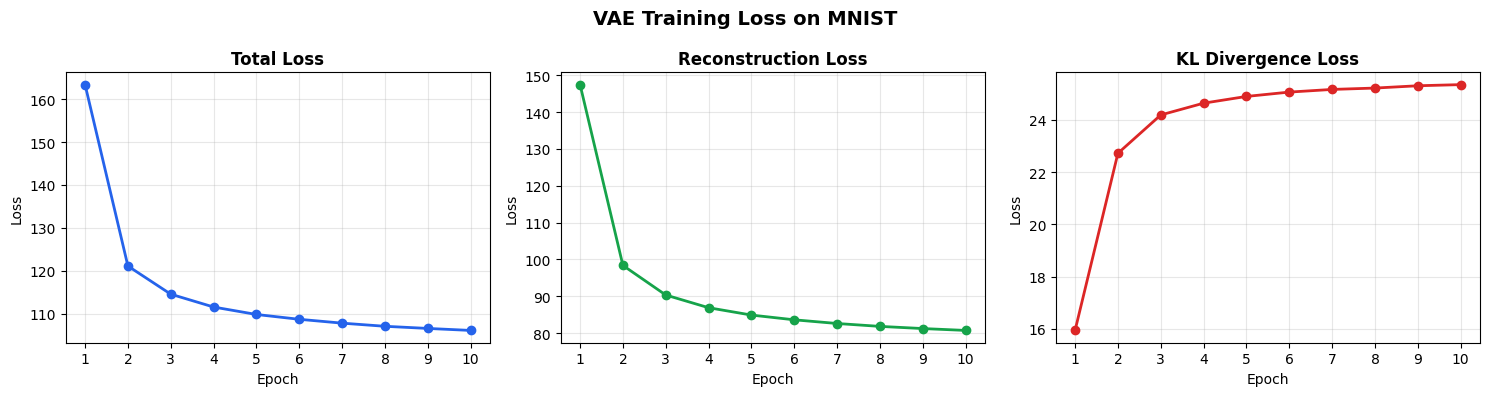

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("VAE Training Loss on MNIST", fontsize=14, fontweight="bold")

labels   = ["Total Loss", "Reconstruction Loss", "KL Divergence Loss"]
keys     = ["total",      "recon",               "kl"]
colors   = ["#2563EB",    "#16A34A",              "#DC2626"]

for ax, label, key, color in zip(axes, labels, keys, colors):
    ax.plot(range(1, EPOCHS + 1), history[key], marker="o", color=color, linewidth=2)
    ax.set_title(label, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.grid(True, alpha=0.3)
    ax.set_xticks(range(1, EPOCHS + 1))

plt.tight_layout()
plt.show()

**Original vs Reconstructed:**

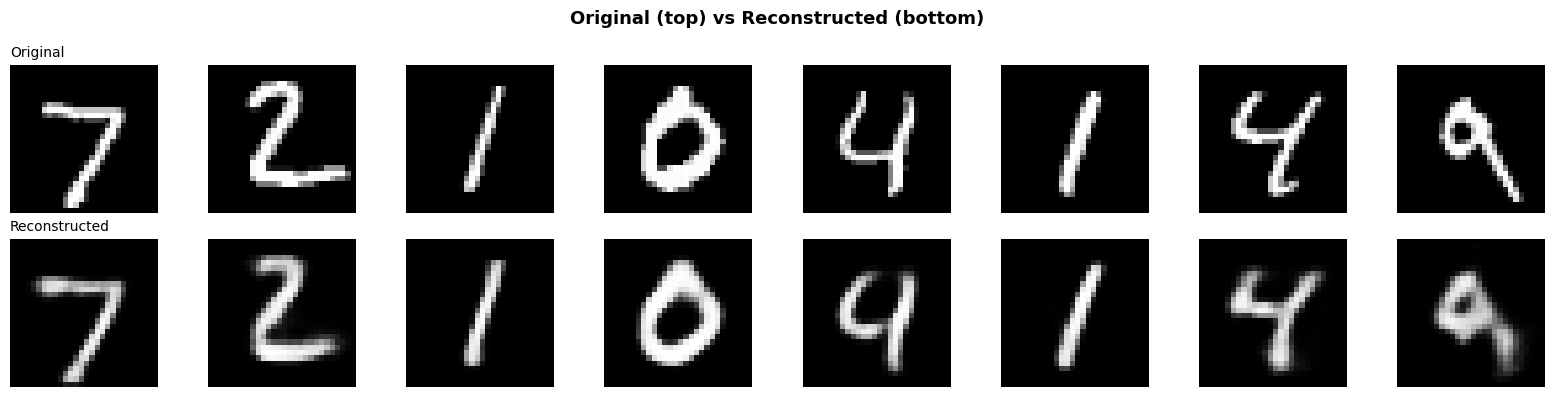

In [14]:
n = 8
originals     = x_test.cpu().view(n, 28, 28).numpy()
reconstructed = x_hat.cpu().view(n, 28, 28).numpy()

fig, axes = plt.subplots(2, n, figsize=(16, 4))
fig.suptitle("Original (top) vs Reconstructed (bottom)", fontsize=13, fontweight="bold")

for i in range(n):
    axes[0, i].imshow(originals[i],     cmap="gray", vmin=0, vmax=1)
    axes[1, i].imshow(reconstructed[i], cmap="gray", vmin=0, vmax=1)
    for row in range(2):
        axes[row, i].axis("off")

axes[0, 0].set_title("Original",      fontsize=10, loc="left")
axes[1, 0].set_title("Reconstructed", fontsize=10, loc="left")

plt.tight_layout()
plt.show()

**Generated samples:**

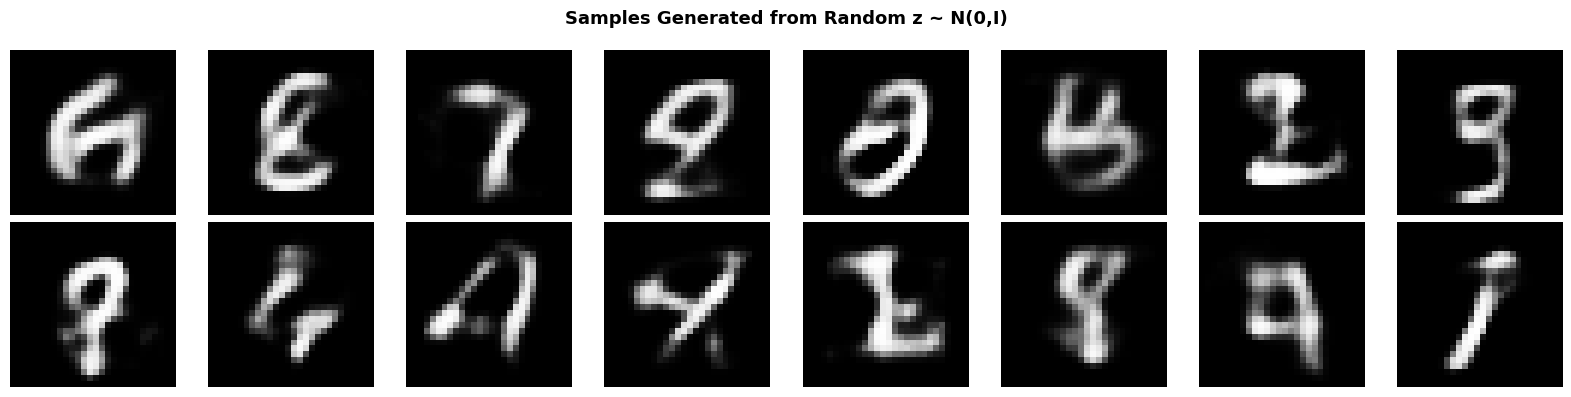

In [15]:
model.eval()
with torch.no_grad():
    z_random   = torch.randn(16, LATENT_DIM).to(DEVICE)
    generated  = model.decode(z_random).cpu().view(16, 28, 28).numpy()

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
fig.suptitle("Samples Generated from Random z ~ N(0,I)", fontsize=13, fontweight="bold")

for i, ax in enumerate(axes.flat):
    ax.imshow(generated[i], cmap="gray", vmin=0, vmax=1)
    ax.axis("off")

plt.tight_layout()
plt.show()